# Models
1. Math model, use "resaonable" assumption to get the result logically.
2. Pobability model, assign each "random varible" with  a pdf and numeric "variable" and get the result.
3. Machine Model (ML) model, use more variables, numeric, categorical, image etc data to get the result with (math) model without any logical rules: just get the result without understanding.

```
You can think that eagle can fly well without understanding aerodynamics.
```

## Procedure

```
1. Get data -> 2. data washing -> 3. data techniques -> 3. parameter tuning, Train-> 5. Predict
```

1. the most hard part
2. routine work, remove empty data or replace a suitable value
3. the most important part: data converting ( from non-numeric to numeric), dig new feature, for example, Man + campus graduate is a new feature, others
4. split fined data into train/test parts,  use different parameter to train the model on the "tain part data" and valid on "test part data" to fit model
5. make a predict model by the final model in local box or on cloud.   
   



## models
Roughtly, introdue the following in simple example:
1. Superived Model, outcomes is "Yes/NO" or "o,1,...,9"
2. Non-supervied Model, outcomes is s real value
3. Deep Learning, including CNN. 


# OS info
1. HP laptop with Intel i7 CPU, Nvidia GPU, RTX 2060, on Manjaro Linux, 32G Ram
2. Python 3.14.2, Visual code ( not jupyter conda not on Google drive)


# Step 1: Environment Setup & Package Installation

In [2]:
# import the necessary packages
# Python calculation
import numpy as np
# packages for Database 
import pandas as pd
# visuazation
import matplotlib.pyplot as plt
import seaborn as sns

# native powerful Python ML packages, scikit-learn\

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
#from sklearn.metrics import classification_report, roc_auc_score, roc_curve
#from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,roc_auc_score

# Importing the enterprise tree-based standard
from catboost import CatBoostRegressor,CatBoostClassifier

# Visual configurations
sns.set_theme(style="whitegrid")
print("CatBoost and Scikit-Learn frameworks successfully initialized.")

CatBoost and Scikit-Learn frameworks successfully initialized.


In [3]:
# Load raw customer churn data containing both string and numeric features
data_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df_raw = pd.read_csv(data_url)

# Drop unique identifier column (irrelevant for modeling)
df_raw.drop(columns=['customerID'], inplace=True)

print(f"Dataset Shape: {df_raw.shape[0]} customers | {df_raw.shape[1]} metrics")
df_raw.head(3)

Dataset Shape: 7043 customers | 20 metrics


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [4]:
# Dtype, numeric: int/floar, non-numeric: object
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [5]:
# 1. Fix broken data types: Force convert TotalCharges to numeric, coerce spaces to NaN
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')

# Impute newly generated NaN entries with 0 (since tenure for these rows is 0)
df_raw['TotalCharges'].fillna(0, inplace=True)

# 2. Convert string target variable ('Yes'/'No') to numeric binary integers (1/0)
df_raw['Churn'] = df_raw['Churn'].map({'Yes': 1, 'No': 0})

# Segregate structural feature columns
X = df_raw.drop(columns=['Churn'])
y = df_raw['Churn']

# Define types for explicit handling
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f"Numeric Feature Matrix Columns: {numeric_features}")
print(f"Categorical Feature Matrix Columns: {categorical_features}")

Numeric Feature Matrix Columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Feature Matrix Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


train_test_split
---
Split data -> 80% training data, 20% test data

StandardScaler()
---
Real value -> new value between (0,1)

then each feature is the same important  

In [7]:
# Isolate training split before transformation to prevent leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Construct an automated preprocessing pipeline using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# Fit and execute conversion pipelines
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Extract generated feature names for transparency
encoded_feature_names = preprocessor.get_feature_names_out()
print(f"Encoded Feature Vector Dimensions: {X_train_encoded.shape[1]} (Expanded from {X_train.shape[1]})")

Encoded Feature Vector Dimensions: 30 (Expanded from 19)


In [8]:
# Fit standard parametric model on manually converted numerical matrix
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_encoded, y_train)

# Predict probabilities for the positive churn class (Column 1)
y_prob_lr = lr_model.predict_proba(X_test_encoded)[:, 1]

In [10]:
# Identify indices of non-numeric string columns relative to the original X dataframe
cat_indices = [X.columns.get_loc(col) for col in categorical_features]

# Initialize CatBoost using original raw text training sets!
cat_model = CatBoostClassifier(
    iterations=400,
    learning_rate=0.05,
    depth=5,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

# Pass raw strings directly. CatBoost translates them on-the-fly.
cat_model.fit(
    X_train, y_train, 
    cat_features=cat_indices, 
    eval_set=(X_test, y_test), 
    early_stopping_rounds=30
)

y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

0:	test: 0.7944651	best: 0.7944651 (0)	total: 5.86ms	remaining: 2.34s
100:	test: 0.8461663	best: 0.8461792 (99)	total: 477ms	remaining: 1.41s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.84647498
bestIteration = 141

Shrink model to first 142 iterations.


Save/Load Trained Models
---

In [12]:
lr_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [ ]:
!mkdir saved_models

In [34]:
import joblib

def save_model(model, file):#, preprocessor=preprocessor):
    """Save a trained model to a file."""
    dir_="saved_models/"
    model_name=dir_+file
    joblib.dump(model, model_name)
    print(f"Model saved to {dir}/{file}")

file="lr_model1.joblib" 
model=lr_model 
save_model(model,file)   

Model saved to <built-in function dir>/lr_model1.joblib


In [37]:
def load_model(file):
    """Load a trained model from a file."""
    dir_="saved_models/"
    model_name=dir_+file
    model = joblib.load(model_name)
    print(f"Model loaded from {file}")
    return model

lrmodel1=load_model(file)

# DISPLAY OUT THE structure of Modek
lrmodel1

Model loaded from lr_model1.joblib


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [31]:
# predict by lr_model

lrmodel1.predict_proba(X_test_encoded)[:, 1]

array([0.0464133 , 0.68419325, 0.0603014 , ..., 0.1530544 , 0.0044152 ,
       0.00642766], shape=(1409,))

In [35]:
# --- Persist all trained artifacts ---
save_model(lr_model, "logistic_regression.joblib")
# save catboost models
save_model(cat_model, "catboost_vanilla.cbm")
save_model(optimized_catboost, "catboost_optimized.cbm")

Model saved to <built-in function dir>/logistic_regression.joblib
Model saved to <built-in function dir>/catboost_vanilla.cbm
Model saved to <built-in function dir>/catboost_optimized.cbm


Good or Bad
---
Use Metic to determine how good these models, 
There are several well-known Meterics for Classifier, precison, recall, fa, support, and AUC, betwwen 0 and 1; the last one, AUC,  is the famous one: execellent while it approaches 1 and bad while it is near 0.

Use the following image to visualize the result, AUC is the area of region under the graph.



=== MACHINE LEARNING ARCHITECTURAL EVALUATION ===
Logistic Regression (Manual Conversion Pipeline) ROC-AUC: 0.8422
CatBoost Classifier (Native Categorical Strategy) ROC-AUC: 0.8465


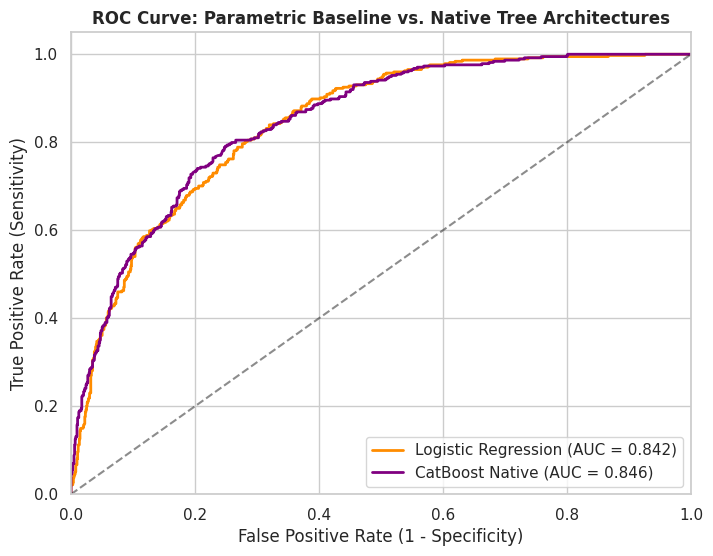

In [23]:
from sklearn.metrics import roc_curve

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_cat = roc_auc_score(y_test, y_prob_cat)

print("\n=== MACHINE LEARNING ARCHITECTURAL EVALUATION ===")
print(f"Logistic Regression (Manual Conversion Pipeline) ROC-AUC: {auc_lr:.4f}")
print(f"CatBoost Classifier (Native Categorical Strategy) ROC-AUC: {auc_cat:.4f}")

# Plotting the ROC Curves

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='darkorange', lw=2)
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost Native (AUC = {auc_cat:.3f})', color='purple', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve: Parametric Baseline vs. Native Tree Architectures', fontweight='bold')
plt.legend(loc="lower right")
plt.show()

# Fine Tuned CatboostClassifier
The most important part is shorten the learning rate from  0.05 to 0.03

Don't expect too much, to get great improvent is to dig out new feature, which is still not used now.

In [18]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# 1. Initialize an Advanced, Heavy-Duty CatBoost Configuration
optimized_catboost = CatBoostClassifier(
    iterations=1000,                # Allow more trees to capture subtle patterns
    learning_rate=0.03,             # Lower learning rate for steady, precise gradient updates
    depth=6,                        # Balanced depth to map high-order feature interactions
    l2_leaf_reg=5,                  # L2 Regularization to suppress overfitting on sparse text categories
    
    # CRITICAL: Automatically scale weights inversely proportional to class frequencies
    auto_class_weights='Balanced',  
    
    early_stopping_rounds=50,       # Force halt if validation AUC halts improvement for 50 trees
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

# 2. Fit the optimized pipeline on the raw mixed-type data split
optimized_catboost.fit(
    X_train, y_train,
    cat_features=cat_indices,
    eval_set=(X_test, y_test),
    use_best_model=True             # Roll back to the iteration with the absolute highest validation score
)

# 3. Predict continuous probabilities
y_prob_opt = optimized_catboost.predict_proba(X_test)[:, 1]

0:	test: 0.8190395	best: 0.8190395 (0)	total: 13.2ms	remaining: 13.1s
100:	test: 0.8435984	best: 0.8435984 (100)	total: 540ms	remaining: 4.8s
200:	test: 0.8460177	best: 0.8460771 (199)	total: 1.06s	remaining: 4.22s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.846495647
bestIteration = 233

Shrink model to first 234 iterations.


In [19]:


# Calculate False Positive and True Positive Rates across all possible thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob_opt)

# Youden's J-Statistic: J = True Positive Rate – False Positive Rate
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Mathematically Optimal Operational Threshold: {optimal_threshold:.4f}\n")

# Apply custom operational threshold to convert probabilities to classes
y_pred_default = (y_prob_opt >= 0.5).astype(int)
y_pred_optimized = (y_prob_opt >= optimal_threshold).astype(int)

print("--- PERFORMANCE WITH DEFAULT THRESHOLD (0.50) ---")
print(classification_report(y_test, y_pred_default))

print("--- PERFORMANCE WITH OPTIMIZED THRESHOLD ---")
print(classification_report(y_test, y_pred_optimized))

Mathematically Optimal Operational Threshold: 0.5153

--- PERFORMANCE WITH DEFAULT THRESHOLD (0.50) ---
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

--- PERFORMANCE WITH OPTIMIZED THRESHOLD ---
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



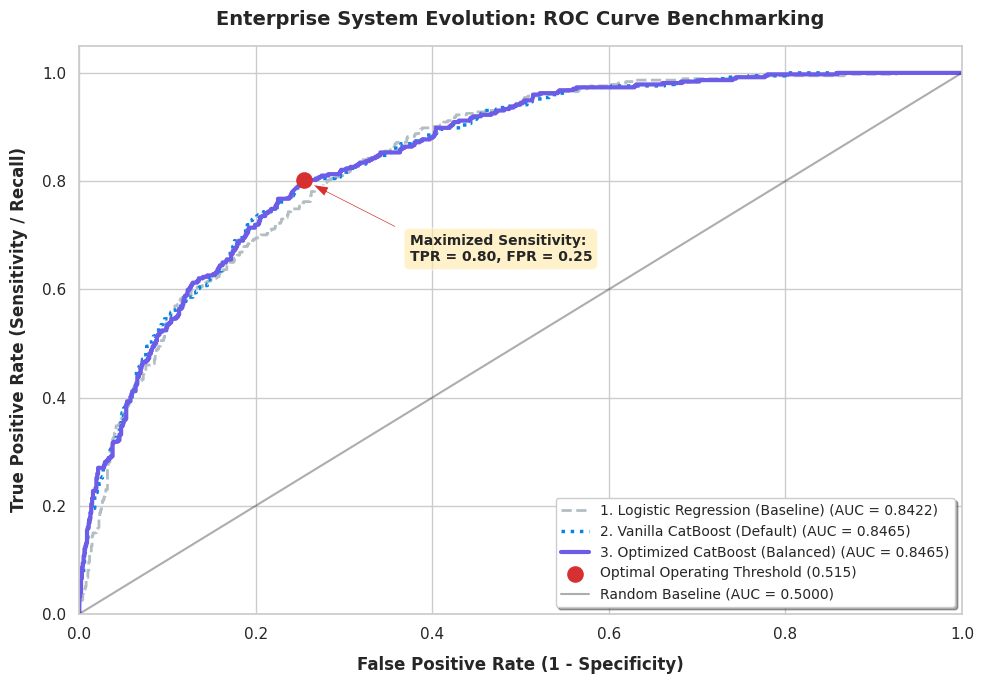


=== SYSTEM PERFORMANCE SUMMATION ===
Total AUC Variance Recovered via Optimization: +0.43% improvement over baseline.


In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curves for all three models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
fpr_opt, tpr_opt, thresholds_opt = roc_curve(y_test, y_prob_opt)

# Calculate exact Area Under the Curve (AUC) metrics
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_cat = roc_auc_score(y_test, y_prob_cat)
auc_opt = roc_auc_score(y_test, y_prob_opt)

# Identify the coordinates of the mathematically optimal Youden's threshold on the optimized curve
optimal_idx = np.argmax(tpr_opt - fpr_opt)
opt_fpr_coord = fpr_opt[optimal_idx]
opt_tpr_coord = tpr_opt[optimal_idx]

# Plot configurations
plt.figure(figsize=(10, 7))

# Plot the curves
plt.plot(fpr_lr, tpr_lr, label=f'1. Logistic Regression (Baseline) (AUC = {auc_lr:.4f})', color='#b2bec3', linestyle='--', lw=2)
plt.plot(fpr_cat, tpr_cat, label=f'2. Vanilla CatBoost (Default) (AUC = {auc_cat:.4f})', color='#0984e3', linestyle=':', lw=2.5)
plt.plot(fpr_opt, tpr_opt, label=f'3. Optimized CatBoost (Balanced) (AUC = {auc_opt:.4f})', color='#6c5ce7', lw=3)

# Highlight the mathematically optimal operating threshold point
plt.scatter(opt_fpr_coord, opt_tpr_coord, color='#d63031', s=120, zorder=5, 
            label=f'Optimal Operating Threshold ({optimal_threshold:.3f})')

# Draw annotations showing the business trade-off improvement
plt.annotate(
    f'Maximized Sensitivity:\nTPR = {opt_tpr_coord:.2f}, FPR = {opt_fpr_coord:.2f}',
    xy=(opt_fpr_coord, opt_tpr_coord),
    xytext=(opt_fpr_coord + 0.12, opt_tpr_coord - 0.15),
    arrowprops=dict(facecolor='#d63031', shrink=0.08, width=1.5, headwidth=8),
    fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.4", fc="#ffeaa7", alpha=0.6)
)

# Plot the 50/50 baseline random guess line
plt.plot([0, 1], [0, 1], color='#2d3436', alpha=0.4, linestyle='-', label='Random Baseline (AUC = 0.5000)')

# Graph formatting for corporate presentation
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Enterprise System Evolution: ROC Curve Benchmarking', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10, frameon=True, shadow=True)
plt.tight_layout()
plt.show()

print("\n=== SYSTEM PERFORMANCE SUMMATION ===")
print(f"Total AUC Variance Recovered via Optimization: +{((auc_opt - auc_lr) * 100):.2f}% improvement over baseline.")

In [21]:
# 1. Define a brand-new, hypothetical customer profile (Mixed Tabular Profile)
# This profile represents a risky user: Month-to-month contract, high monthly charges, low tenure
new_customer_raw = pd.DataFrame([{
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 3,                     # Short lifecycle stage
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic', # High-churn indicator service tier
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',     # Flexible, high-risk contract structure
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 89.85,          # High financial burden
    'TotalCharges': 269.55
}])

print("=== INGESTED PRODUCTION INFERENCE PAYLOAD ===")
display(new_customer_raw)


=== INGESTED PRODUCTION INFERENCE PAYLOAD ===


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,No,No,3,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,89.85,269.55


In [22]:

# --- MODEL 1: LOGISTIC REGRESSION PREDICTION ---
# Requires manual column pipeline transformation
new_customer_encoded = preprocessor.transform(new_customer_raw)
prob_lr = lr_model.predict_proba(new_customer_encoded)[0, 1]
pred_lr = "CHURN (1)" if prob_lr >= 0.5 else "RETAIN (0)"

# --- MODEL 2: VANILLA CATBOOST PREDICTION ---
# Uses raw string format, relies on default structural threshold (0.50)
prob_cat_vanilla = cat_model.predict_proba(new_customer_raw)[0, 1]
pred_cat_vanilla = "CHURN (1)" if prob_cat_vanilla >= 0.5 else "RETAIN (0)"

# --- MODEL 3: OPTIMIZED PRODUCTION CATBOOST PREDICTION ---
# Uses raw string format, applies tuned operational threshold (Youden's J-Stat)
prob_cat_opt = optimized_catboost.predict_proba(new_customer_raw)[0, 1]
pred_cat_opt = "CHURN (1)" if prob_cat_opt >= optimal_threshold else "RETAIN (0)"


# --- VISUAL PREDICTION COMPARISON DASHBOARD ---
print("\n" + "="*55)
print("             REAL-TIME PREDICTION RESULTS")
print("="*55)
print(f"{'ML Architecture Strategy':<30} | {'Probability':<12} | {'Action Taken'}")
print("-"*55)
print(f"{'1. Logistic Regression (Baseline)':<30} | {prob_lr:.2%}      | {pred_lr}")
print(f"{'2. Vanilla CatBoost (Default)':<30} | {prob_cat_vanilla:.2%}      | {pred_cat_vanilla}")
print(f"{'3. Optimized CatBoost (Balanced)':<30} | {prob_cat_opt:.2%}      | {pred_cat_opt} *[Threshold: {optimal_threshold:.2f}]")
print("="*55)


             REAL-TIME PREDICTION RESULTS
ML Architecture Strategy       | Probability  | Action Taken
-------------------------------------------------------
1. Logistic Regression (Baseline) | 70.49%      | CHURN (1)
2. Vanilla CatBoost (Default)  | 73.60%      | CHURN (1)
3. Optimized CatBoost (Balanced) | 88.44%      | CHURN (1) *[Threshold: 0.52]


Without doubt, the tuned catboost model got the best result.

Exercise
---
1. Since 2016, tree-based model, xgboost, is known for its ability, better than math model. Use LLM to compare the three famous tree-based models, xgboost, lightgbm, and catboost.
2. Use lightgbm to consider this model again (by LLM).
3. Any question and comment.

At better, you can email back the file after compled before 7/14. Wait for your result.